## **Types of Ensemble Voting**


1. Hard Voting (Majority Rule)

Hard voting is based on a simple democratic majority. Each individual classifier "votes" for a class label, and the class that receives the most votes is chosen as the final prediction.

- Mechanism: It uses the predicted class labels ($0, 1, 2, \dots$) from each model.
- Best For: When your base models are "uncalibrated" or don't provide reliable probability estimates (e.g., some Support Vector Machines or simple Decision Trees).
- Logic: If 3 models predict "Spam" and 2 predict "Not Spam," the ensemble predicts "Spam."


2. Soft Voting (Average Probability)

Soft voting is more nuanced because it considers the confidence of each model. Instead of looking at the final label, it averages the predicted probabilities ($0.0$ to $1.0$) for each class across all models.

- Mechanism: It averages the probability scores for each class. The class with the highest average probability wins.
- Best For: When models are well-calibrated (their probabilities reflect actual likelihood). It generally performs better than hard voting because it gives more weight to highly confident models.
- Logic: Even if 2 models barely vote "A" (51%), if 1 model strongly votes "B" (90%), soft voting may pick "B" as the winner.





# **Voting Classification**

In [159]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC


import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [160]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['Species'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [161]:
df = pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [162]:
df['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [163]:
# df = df.iloc[:,1:]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [164]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [165]:
df['species'].unique()

array([0, 1, 2])

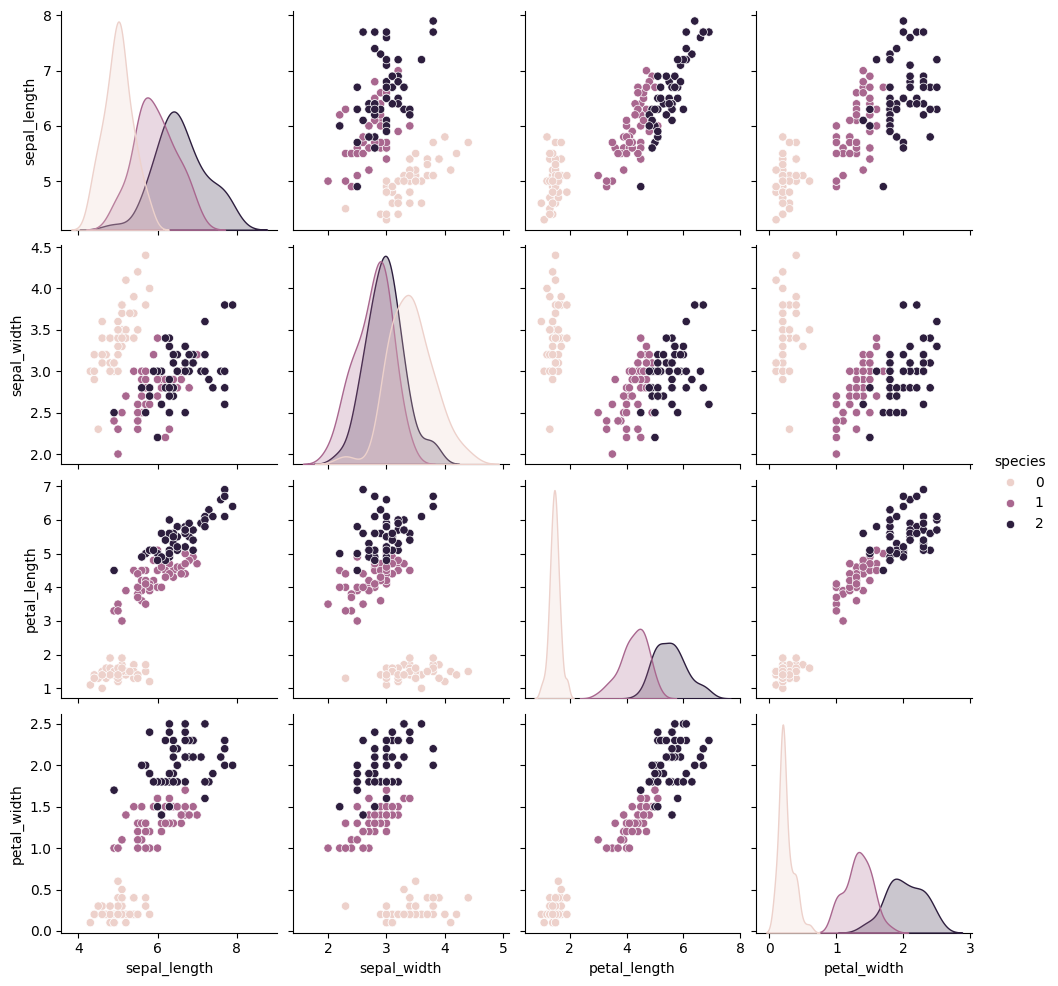

In [166]:
sns.pairplot(df,hue='species')
plt.show()


In [167]:
new_df = df[df['species'] != 0][['sepal_length','sepal_width','species']]
new_df.head()


,sepal_length,sepal_width,species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


### **Doing Ensemble Voting**

In [168]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

estimators = [('lr',clf1),('rf',clf2),('knn',clf3)]

for estimator in estimators:
  x = cross_val_score(estimator[1], X, y, cv=10, scoring='accuracy')
  print(estimator[0], np.round(np.mean(x), 2))




lr 0.81
rf 0.71
knn 0.76


### **Hard Voting**

In [ ]:
vc = VotingClassifier(estimators = estimators, voting='hard')       # we use voting classifier for classification problems
x = cross_val_score(vc, X, y, cv=10, scoring='accuracy')
print(np.round(np.mean(x),2))

0.76


### **Soft Voting**

In [170]:
vc1 = VotingClassifier(estimators = estimators, voting='soft')
x = cross_val_score(vc1, X, y, cv=10, scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


it might not have increased the accuracy, but usually while doing soft voting, it increases the accuracy.

### **Weighted Voting**

In [171]:
for i in range(1, 4):
  for j in range(1, 4):
    for k in range(1, 4):
      vc = VotingClassifier(estimators=estimators, voting='soft', weights=[i, j, k])
      x = cross_val_score(vc, X, y, cv=10, scoring='accuracy')
      print("for i={}, j={}, k={}".format(i,j,k), np.round(np.mean(x), 2))

for i=1, j=1, k=1 0.76
for i=1, j=1, k=2 0.76
for i=1, j=1, k=3 0.76
for i=1, j=2, k=1 0.75
for i=1, j=2, k=2 0.76
for i=1, j=2, k=3 0.76
for i=1, j=3, k=1 0.73
for i=1, j=3, k=2 0.75
for i=1, j=3, k=3 0.75
for i=2, j=1, k=1 0.79
for i=2, j=1, k=2 0.77
for i=2, j=1, k=3 0.77
for i=2, j=2, k=1 0.77
for i=2, j=2, k=2 0.77
for i=2, j=2, k=3 0.77
for i=2, j=3, k=1 0.75
for i=2, j=3, k=2 0.76
for i=2, j=3, k=3 0.77
for i=3, j=1, k=1 0.81
for i=3, j=1, k=2 0.79
for i=3, j=1, k=3 0.79
for i=3, j=2, k=1 0.79
for i=3, j=2, k=2 0.76
for i=3, j=2, k=3 0.76
for i=3, j=3, k=1 0.77
for i=3, j=3, k=2 0.77
for i=3, j=3, k=3 0.76


### **Classifiers of Same Algorithm**

In [ ]:
from sklearn.datasets import make_classification

# here we are making random dataset, and using same ml model ie SVC to create 5 models with different degrees

X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=2
)

# SVC = support vector classifier
svm1 = SVC(probability=True, kernel='poly', degree=1)
svm2 = SVC(probability=True, kernel='poly', degree=2)
svm3 = SVC(probability=True, kernel='poly', degree=3)
svm4 = SVC(probability=True, kernel='poly', degree=4)
svm5 = SVC(probability=True, kernel='poly', degree=5)

estimators = [('svm1',svm1),('svm2',svm2),('svm3',svm3),('svm4',svm4),('svm5',svm5)]

for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))




svm1 0.85
svm2 0.85
svm3 0.89
svm4 0.81
svm5 0.86


In [173]:
vc1 = VotingClassifier(estimators = estimators, voting='hard')
x = cross_val_score(vc1, X, y, cv=10, scoring='accuracy')
print(np.round(np.mean(x), 2))

0.91


In [174]:
vc1 = VotingClassifier(estimators = estimators, voting='soft')
x = cross_val_score(vc1, X, y, cv=10, scoring='accuracy')
print(np.round(np.mean(x), 2))

0.93



As you can see, the accuracy has increased by 2 % in soft voting.